# 03 · Predictive machine learning: P(conversion | X)

The "who converts" model, deliberately separate from "who converts *because of* the ad". Treatment is not a feature.
Models: logistic regression (interpretable baseline), random forest, LightGBM. Conversion is 0.29% positive, so
accuracy is meaningless (predicting "no" everywhere is 99.7% accurate). Full results: `uv run causalml predict --mode full`.

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils import REPO_ROOT

FIG, TAB, MET = (REPO_ROOT / "results" / d for d in ("figures", "tables", "metrics"))
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
pd.set_option("display.max_colwidth", 120)

def fig(name, width=950):
    display(Image(filename=str(FIG / f"{name}.png"), width=width))

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def metrics(name):
    return json.loads((MET / f"{name}.json").read_text())

In [2]:
pred = metrics("predict")
print(pred["why_pr_auc"])
table("predict_test_metrics")

Only ~0.29% of users convert. Accuracy is uninformative (always-no is ~99.7% accurate). ROC-AUC divides false positives by millions of negatives and so looks good even when a flagged list is mostly false positives; PR-AUC's no-skill baseline is the prevalence (base_rate), so its lift over base rate is the honest ranking-quality number.


,model,roc_auc,pr_auc,base_rate,pr_auc_lift_over_base,log_loss,brier,ece,mean_pred,mean_pred_over_base_rate,roc_auc_lo,pr_auc_lo,log_loss_lo,brier_lo,roc_auc_hi,pr_auc_hi,log_loss_hi,brier_hi
0,logistic_regression,0.9558,0.2142,0.002917,73.45,0.01202,0.002533,0.0001196,0.002928,1.004,0.9534,0.205,0.01178,0.002481,0.9581,0.2235,0.01226,0.002585
1,random_forest,0.9531,0.2266,0.002917,77.7,0.01204,0.002504,0.0001515,0.002891,0.9912,0.9505,0.2171,0.01178,0.002452,0.9556,0.2363,0.01229,0.002555
2,lightgbm,0.958,0.2264,0.002917,77.63,0.01181,0.00251,7.936e-05,0.002916,0.9999,0.9557,0.2169,0.01157,0.002459,0.9602,0.236,0.01205,0.002562
3,lightgbm_weighted,0.8731,0.04396,0.002917,15.07,1.332,0.08644,0.146,0.1489,51.06,0.8672,0.04263,1.325,0.08617,0.879,0.0452,1.34,0.08672


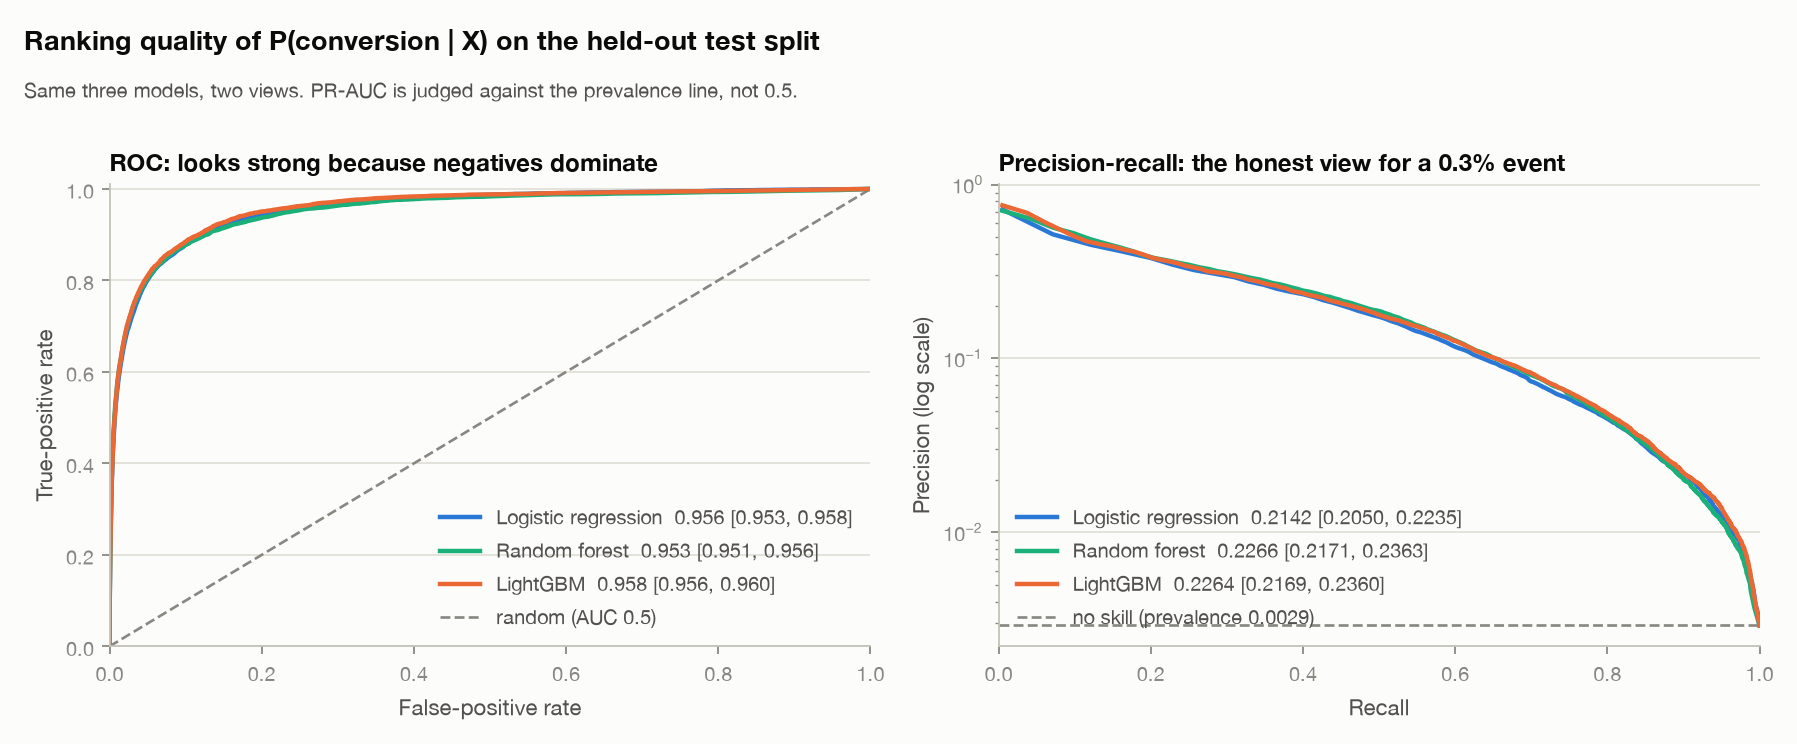

In [3]:
fig("predict_roc_pr")

ROC-AUC looks excellent for every model because it averages over millions of easy negatives. PR-AUC is judged
against the prevalence line; it shows the models are ~75x better than random at ranking converters, and that the
three model families are close.

## Recomputing the headline metrics from the saved test predictions

In [4]:
from src.models.evaluation import classification_metrics
from src.utils import load_config

p = pd.read_parquet(REPO_ROOT / "data/processed/predictions_full.parquet")
test = p[p.split == 2]
pd.DataFrame({m: classification_metrics(test.conversion.to_numpy(), test[f"p_{m}"].to_numpy())
              for m in ["logistic_regression", "random_forest", "lightgbm"]}).T

,roc_auc,pr_auc,base_rate,pr_auc_lift_over_base,log_loss,brier,ece,mean_pred,mean_pred_over_base_rate
logistic_regression,0.9558,0.2142,0.002917,73.45,0.01202,0.002533,0.0001196,0.002928,1.004
random_forest,0.9531,0.2266,0.002917,77.7,0.01204,0.002504,0.0001515,0.002891,0.9912
lightgbm,0.958,0.2264,0.002917,77.63,0.01181,0.00251,7.936e-05,0.002916,0.9999


## Cross-validation and a small hyperparameter search

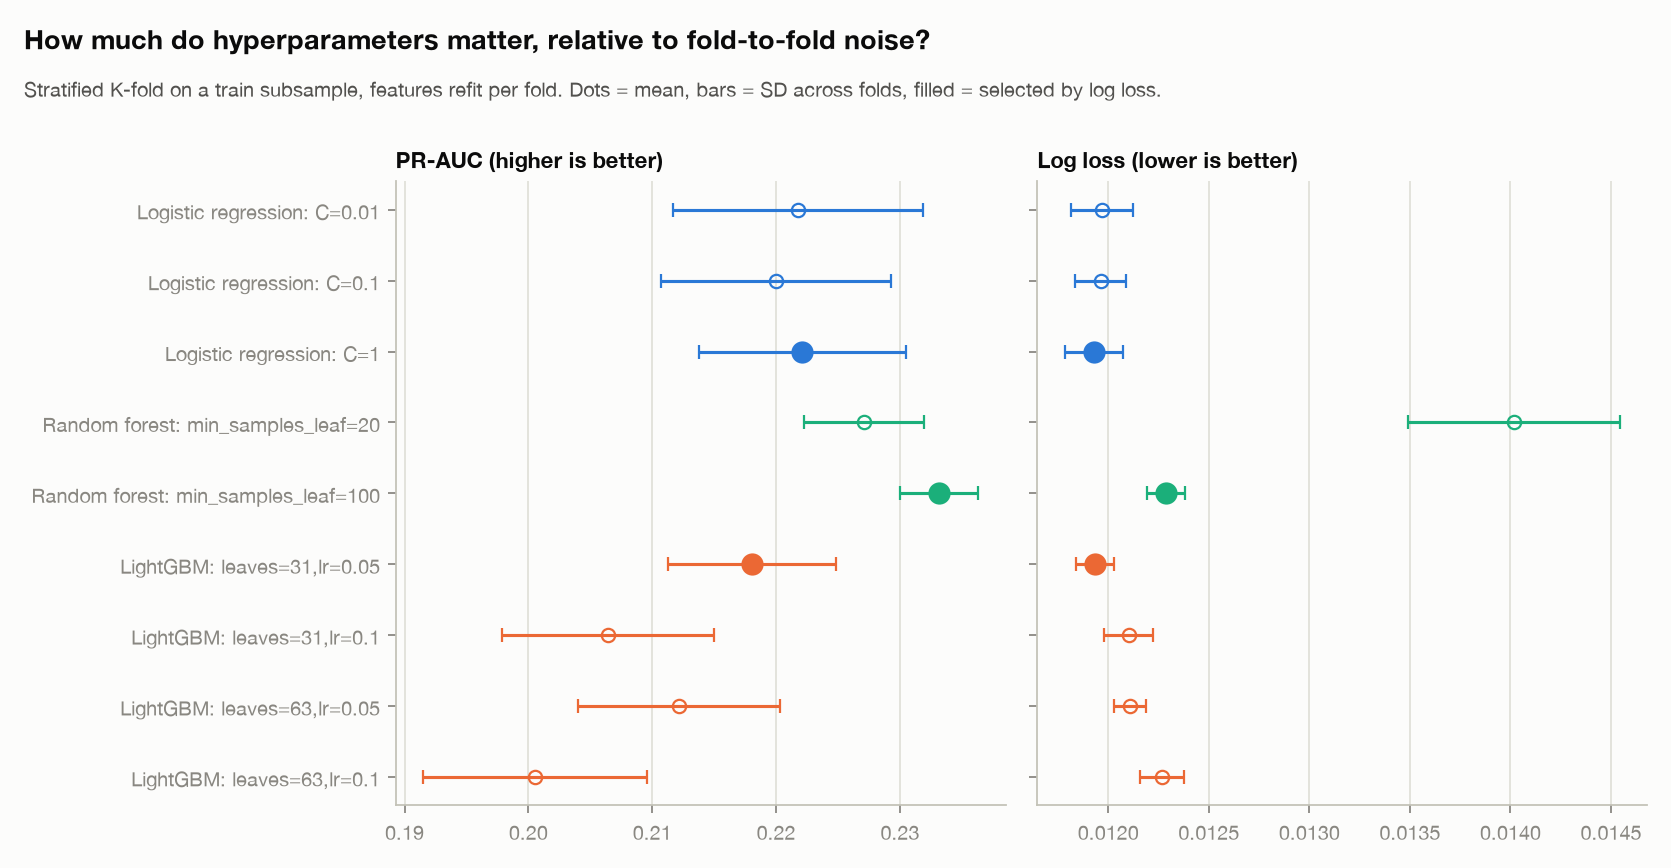

,model,config,roc_auc_mean,pr_auc_mean,log_loss_mean,brier_mean,roc_auc_sd,pr_auc_sd,log_loss_sd,brier_sd,fit_predict_seconds_mean,selected
0,logistic_regression,C=0.01,0.9563,0.2218,0.01197,0.002519,0.001854,0.01009,0.0001542,2.291e-05,2.223,False
1,logistic_regression,C=0.1,0.9557,0.22,0.01196,0.002523,0.001134,0.009293,0.0001268,2.403e-05,1.69,False
2,logistic_regression,C=1,0.9561,0.2221,0.01193,0.002518,0.001599,0.008361,0.0001429,2.243e-05,1.848,True
3,random_forest,min_samples_leaf=20,0.9386,0.2271,0.01402,0.002498,0.005422,0.004866,0.0005253,1.077e-05,36.07,False
4,random_forest,min_samples_leaf=100,0.9516,0.2332,0.01229,0.002489,0.002021,0.003136,9.438e-05,1.024e-05,35.1,True
5,lightgbm,"leaves=31,lr=0.05",0.9568,0.2181,0.01193,0.002523,0.001729,0.006761,9.259e-05,1.571e-05,8.746,True
6,lightgbm,"leaves=31,lr=0.1",0.9559,0.2064,0.0121,0.002555,0.001682,0.008582,0.0001236,1.626e-05,4.45,False
7,lightgbm,"leaves=63,lr=0.05",0.9547,0.2122,0.01211,0.00254,0.001575,0.008143,8.023e-05,1.715e-05,12.73,False
8,lightgbm,"leaves=63,lr=0.1",0.9541,0.2005,0.01227,0.002572,0.001204,0.009022,0.000108,1.799e-05,6.384,False


In [5]:
fig("predict_cv"); table("predict_cv_comparison")

## Class imbalance: reweighting is not free

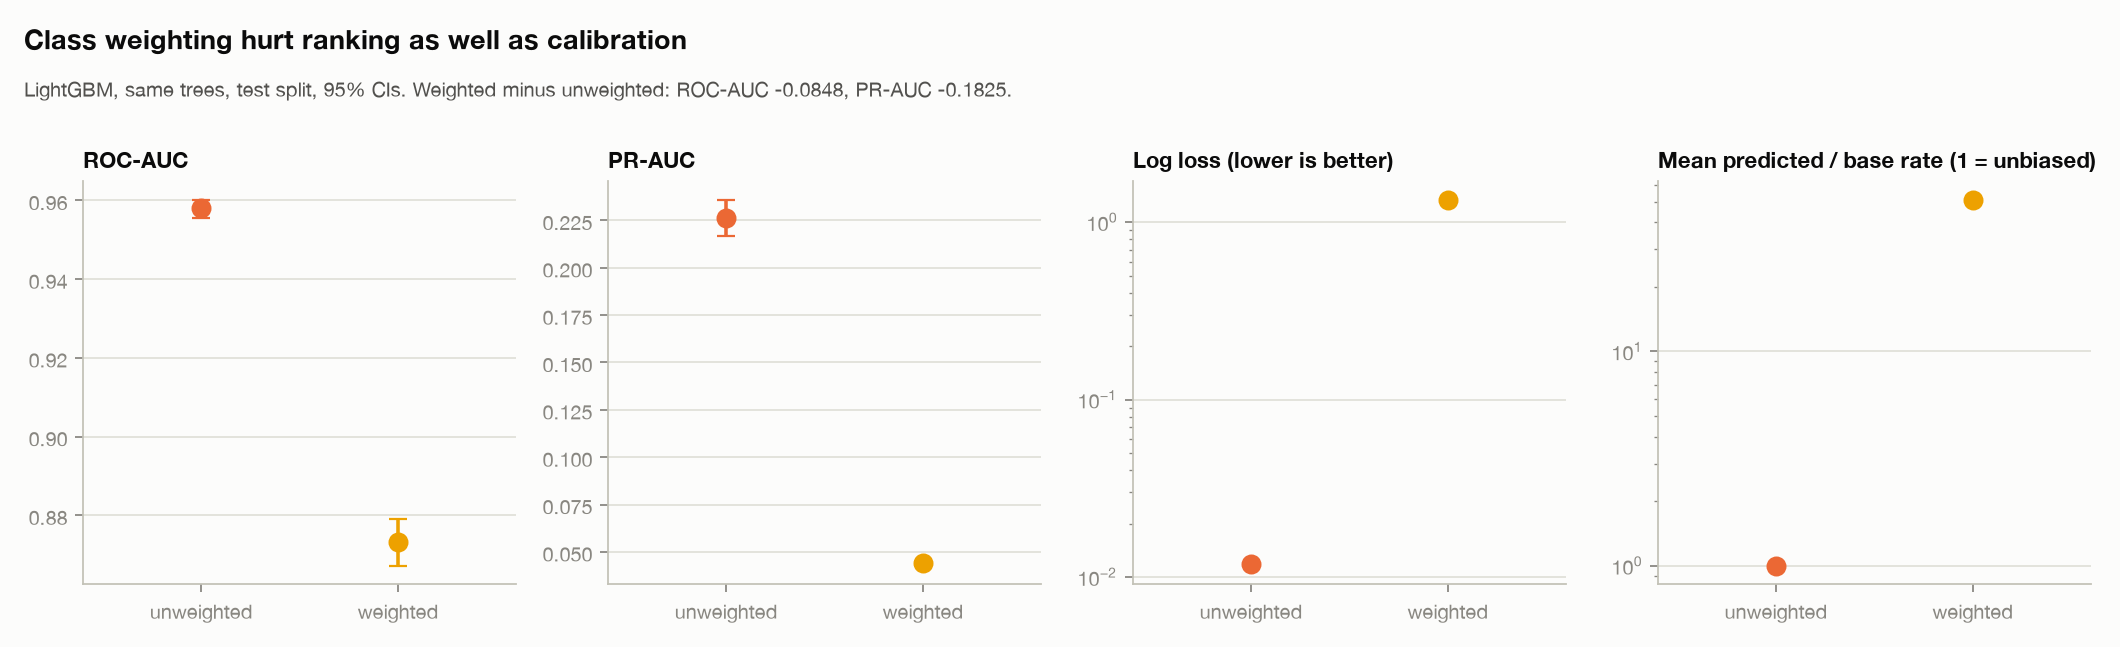

In [6]:
fig("predict_imbalance_tradeoff")

## Calibration

Targeting decisions multiply probabilities by money (expected value = p × value − cost), so a model that
over-predicts by 2x doubles the perceived value of every user. The unweighted models are already close to calibrated;
Platt and isotonic calibration (fit on validation only) barely move log loss. The class-weighted model is badly
miscalibrated until recalibrated.

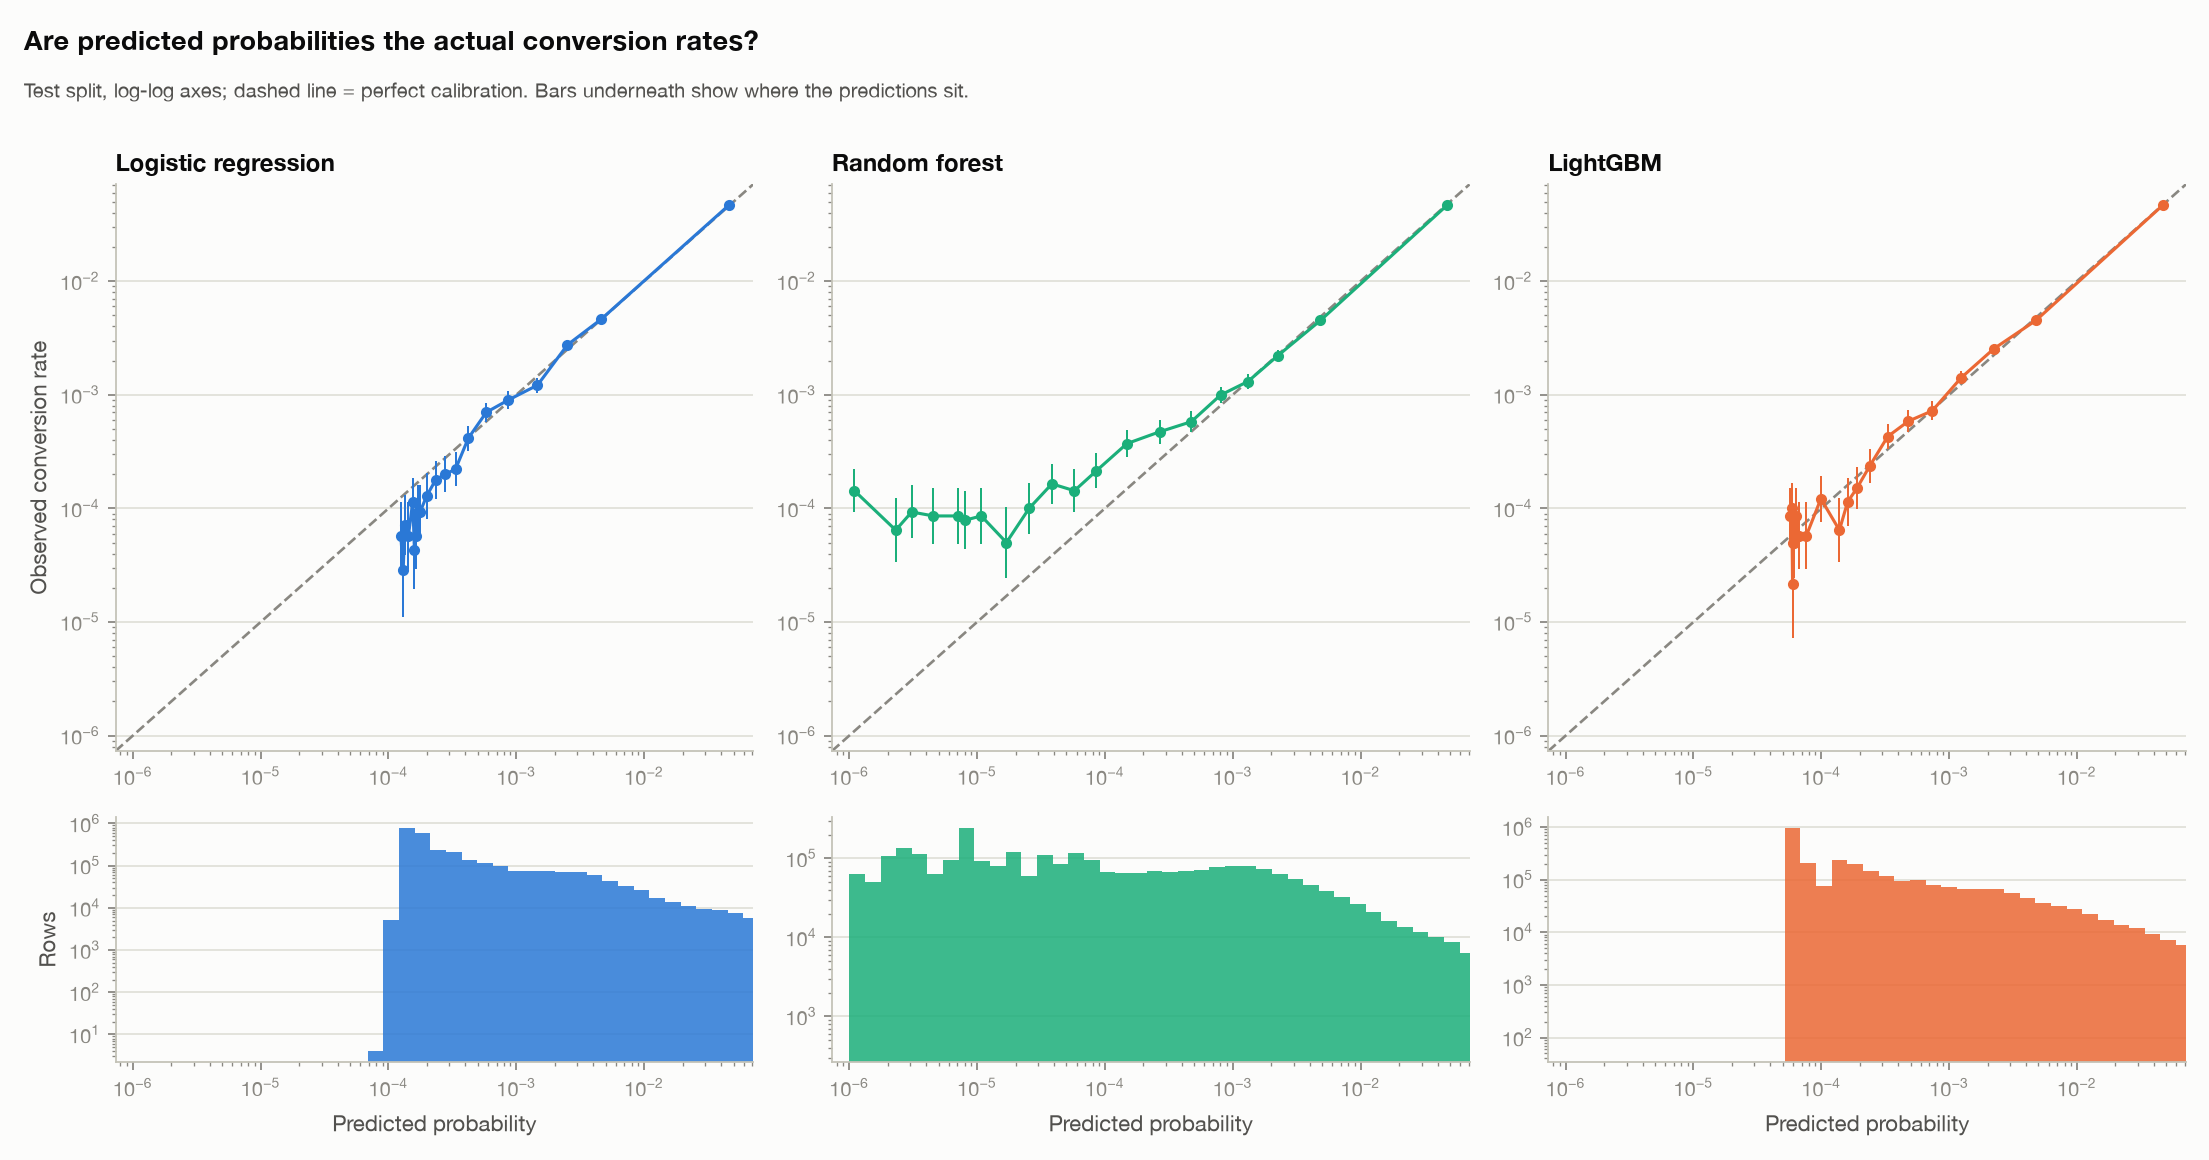

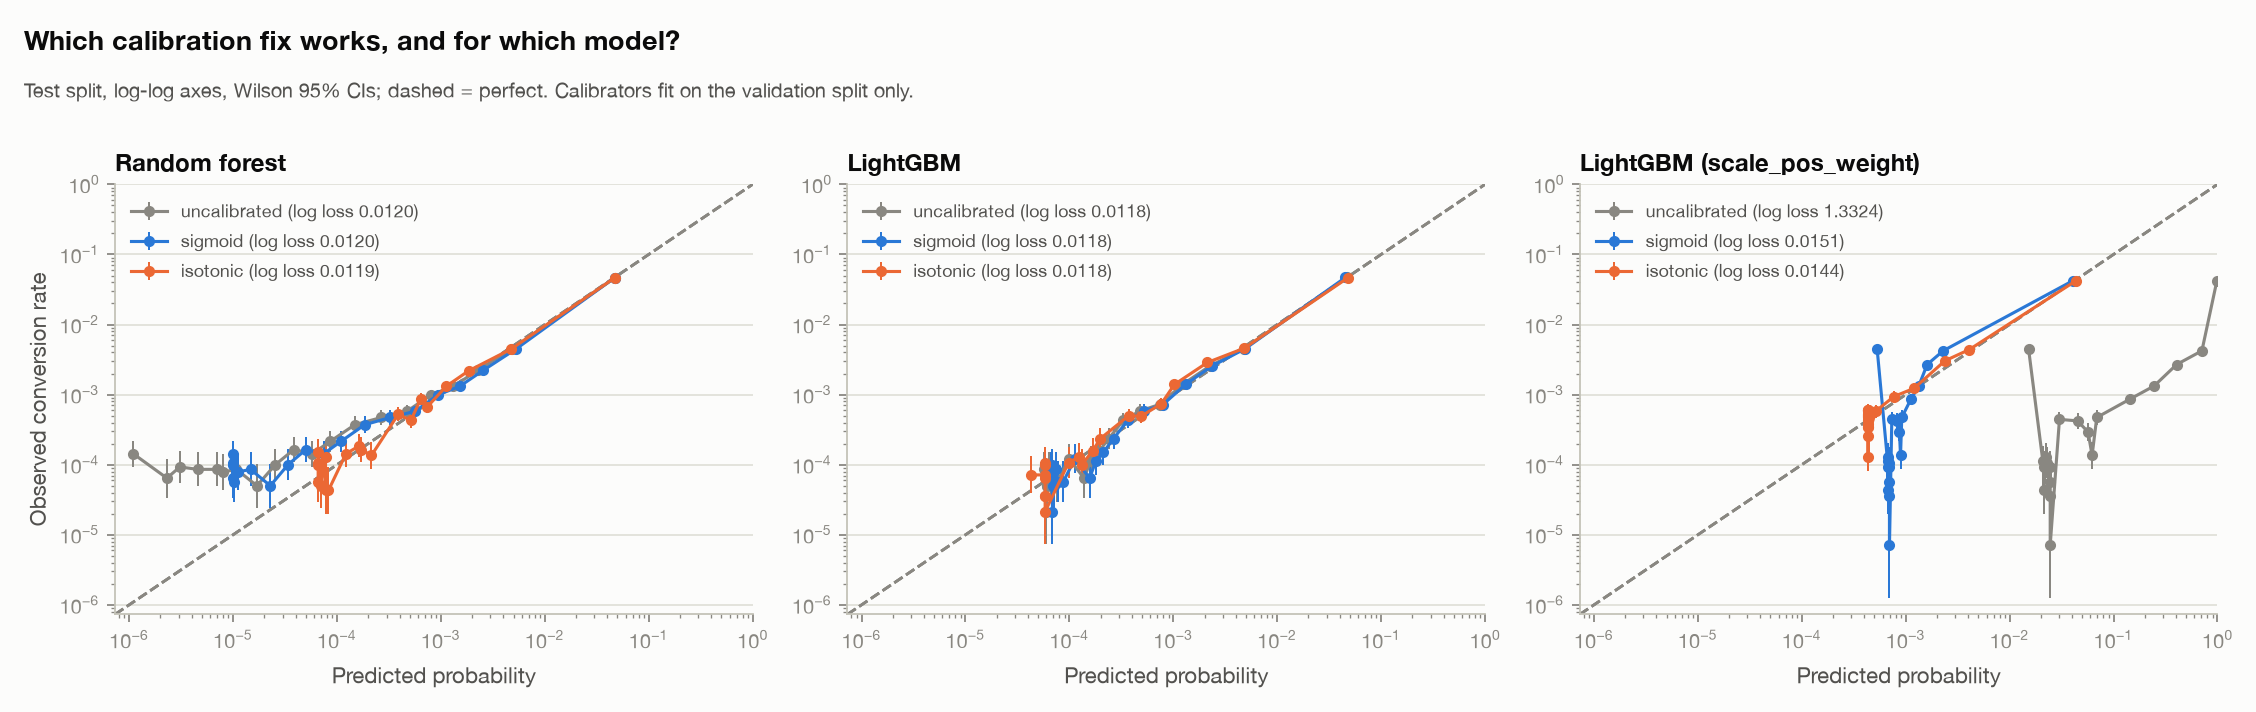

,model,method,selected,roc_auc,pr_auc,base_rate,pr_auc_lift_over_base,log_loss,brier,ece,mean_pred,mean_pred_over_base_rate,log_loss_lo,log_loss_hi,brier_lo,brier_hi
0,logistic_regression,uncalibrated,False,0.9558,0.2142,0.002917,73.45,0.01202,0.002533,0.0001196,0.002928,1.004,0.01178,0.01226,0.002481,0.002585
1,logistic_regression,sigmoid,False,0.9558,0.2142,0.002917,73.45,0.01202,0.00253,0.0002455,0.002827,0.9691,0.01178,0.01226,0.002478,0.002583
2,logistic_regression,isotonic,True,0.9556,0.2059,0.002917,70.6,0.01199,0.002529,0.0001276,0.002918,1.001,0.01175,0.01223,0.002478,0.002581
3,random_forest,uncalibrated,False,0.9531,0.2266,0.002917,77.7,0.01204,0.002504,0.0001515,0.002891,0.9912,0.01178,0.01229,0.002452,0.002555
4,random_forest,sigmoid,False,0.9532,0.2266,0.002917,77.7,0.01195,0.002505,0.0001568,0.002939,1.008,0.01171,0.0122,0.002454,0.002556
5,random_forest,isotonic,True,0.9531,0.2189,0.002917,75.04,0.01192,0.002507,0.0001209,0.002923,1.002,0.01168,0.01216,0.002456,0.002559
6,lightgbm,uncalibrated,False,0.958,0.2264,0.002917,77.63,0.01181,0.00251,7.936e-05,0.002916,0.9999,0.01157,0.01205,0.002459,0.002562
7,lightgbm,sigmoid,True,0.958,0.2264,0.002917,77.63,0.01181,0.002509,0.0001456,0.002857,0.9795,0.01157,0.01205,0.002457,0.002561
8,lightgbm,isotonic,False,0.958,0.2179,0.002917,74.7,0.01182,0.002511,0.0001612,0.002935,1.006,0.01158,0.01206,0.00246,0.002562
9,lightgbm_weighted,uncalibrated,False,0.8731,0.04396,0.002917,15.07,1.332,0.08644,0.146,0.1489,51.06,1.325,1.34,0.08617,0.08672


In [7]:
fig("predict_calibration"); fig("predict_calibration_methods"); table("predict_calibration")

## Operating points (thresholds chosen on validation)

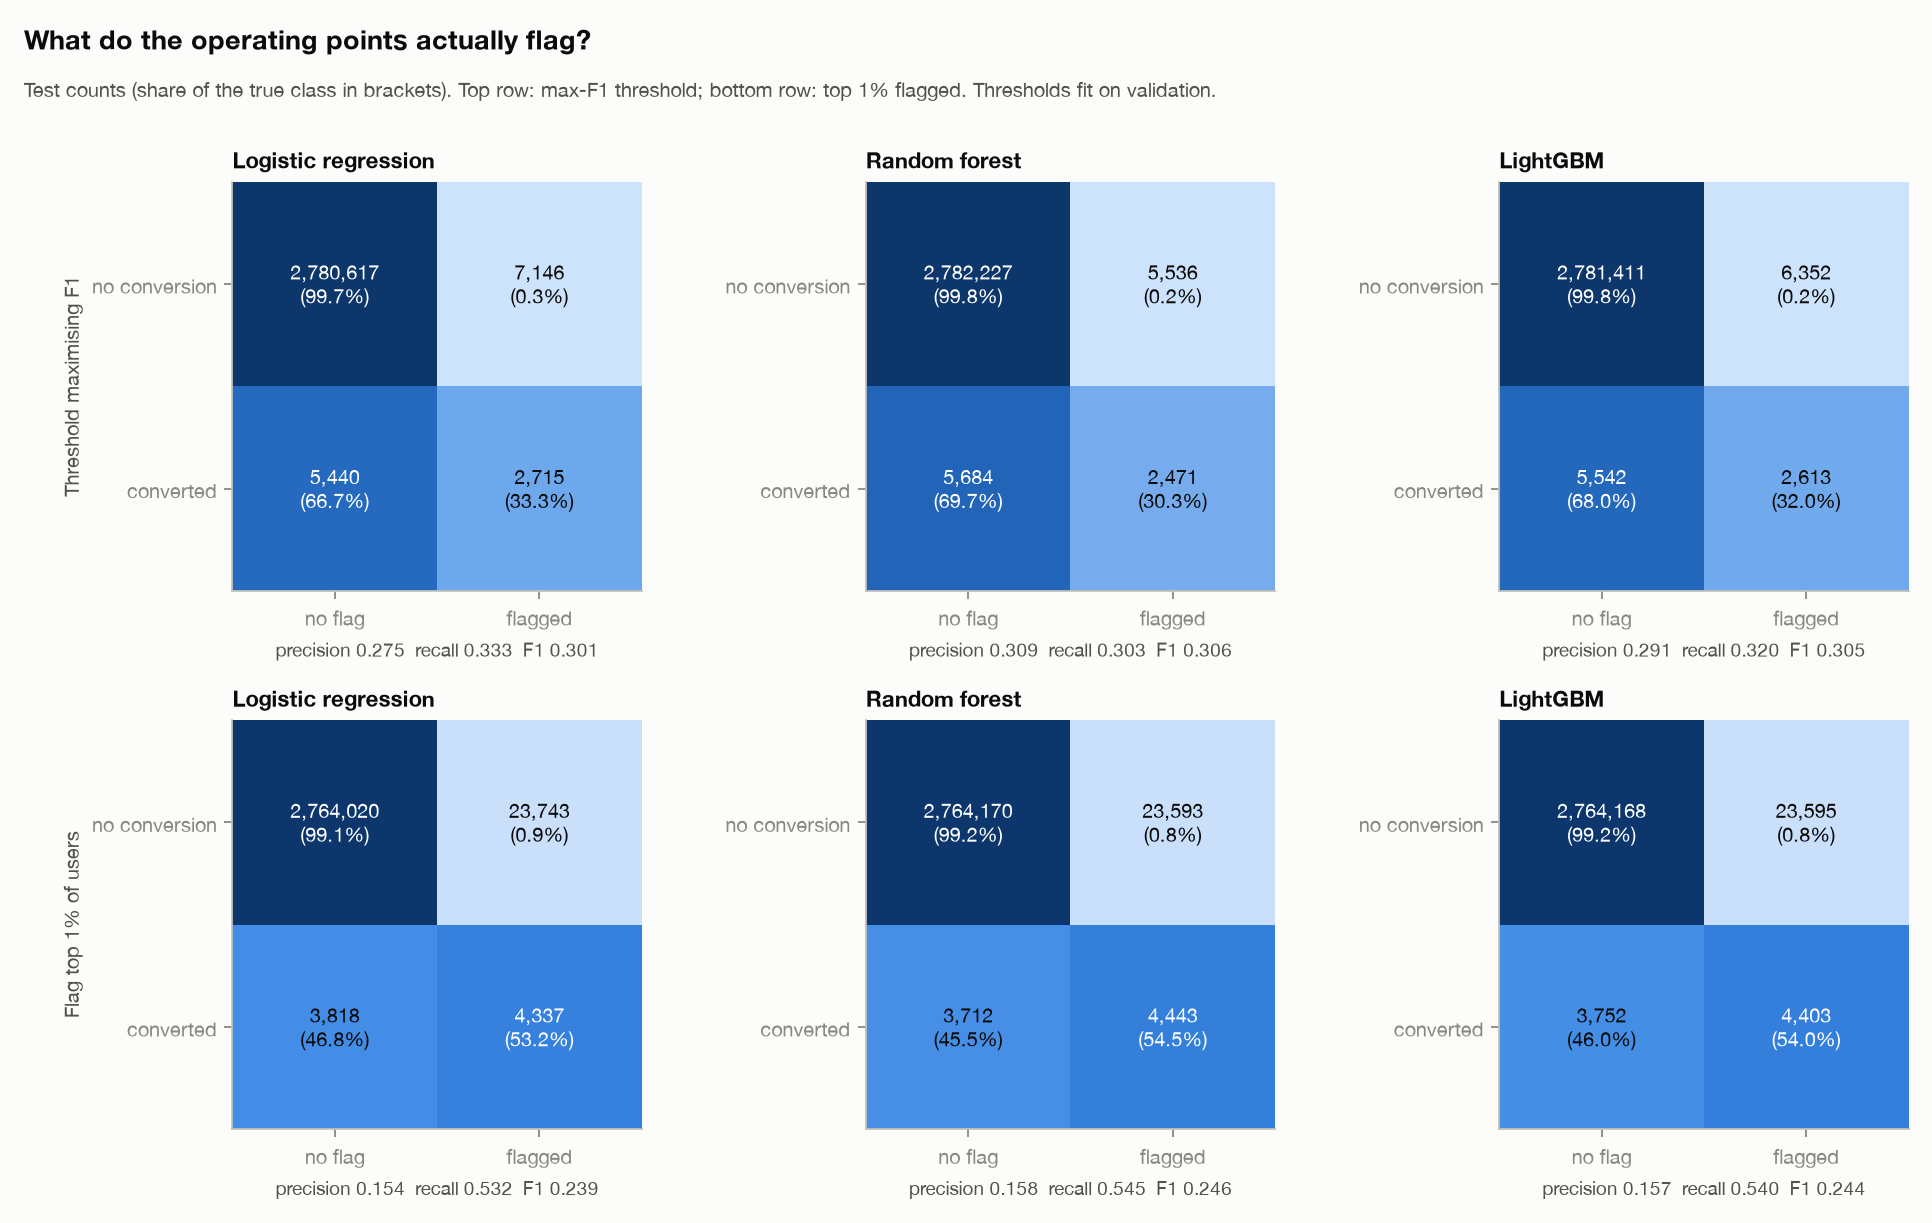

,model,rule,threshold,tp,fp,fn,tn,precision,recall,f1,precision_lo,precision_hi,recall_lo,recall_hi,flagged_fraction,lift_over_base
0,logistic_regression,max_f1,0.1464,2715,7146,5440,2780617,0.2753,0.3329,0.3014,0.2666,0.2842,0.3228,0.3432,0.003527,94.4
1,logistic_regression,top_k,0.05099,4337,23743,3818,2764020,0.1545,0.5318,0.2394,0.1503,0.1587,0.521,0.5426,0.01004,52.95
2,random_forest,max_f1,0.182,2471,5536,5684,2782227,0.3086,0.303,0.3058,0.2986,0.3188,0.2931,0.3131,0.002864,105.8
3,random_forest,top_k,0.05602,4443,23593,3712,2764170,0.1585,0.5448,0.2455,0.1542,0.1628,0.534,0.5556,0.01003,54.33
4,lightgbm,max_f1,0.1709,2613,6352,5542,2781411,0.2915,0.3204,0.3053,0.2822,0.301,0.3104,0.3306,0.003206,99.93
5,lightgbm,top_k,0.05185,4403,23595,3752,2764168,0.1573,0.5399,0.2436,0.153,0.1616,0.5291,0.5507,0.01001,53.92
6,lightgbm_weighted,max_f1,0.9998,5660,93551,2495,2694212,0.05705,0.6941,0.1054,0.05562,0.05851,0.684,0.704,0.03548,19.56
7,lightgbm_weighted,top_k,1,5267,90566,2888,2697197,0.05496,0.6459,0.1013,0.05354,0.05642,0.6354,0.6562,0.03428,18.84


In [8]:
fig("predict_confusion"); table("predict_thresholds")

## Interpretation

Coefficients and importances describe what *predicts* conversion. They say nothing about what the ad *changes*;
notebook 05 compares these rankings with the features that drive the treatment effect.

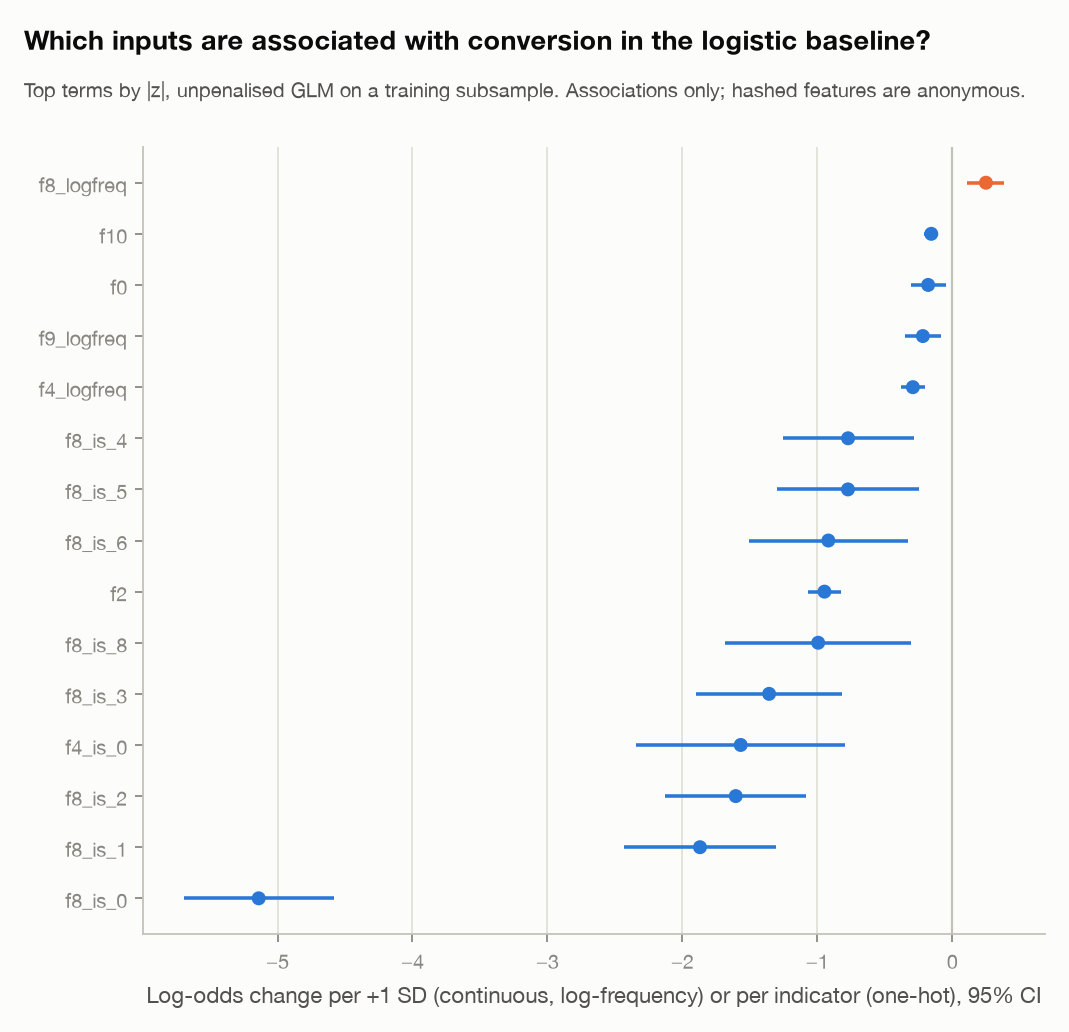

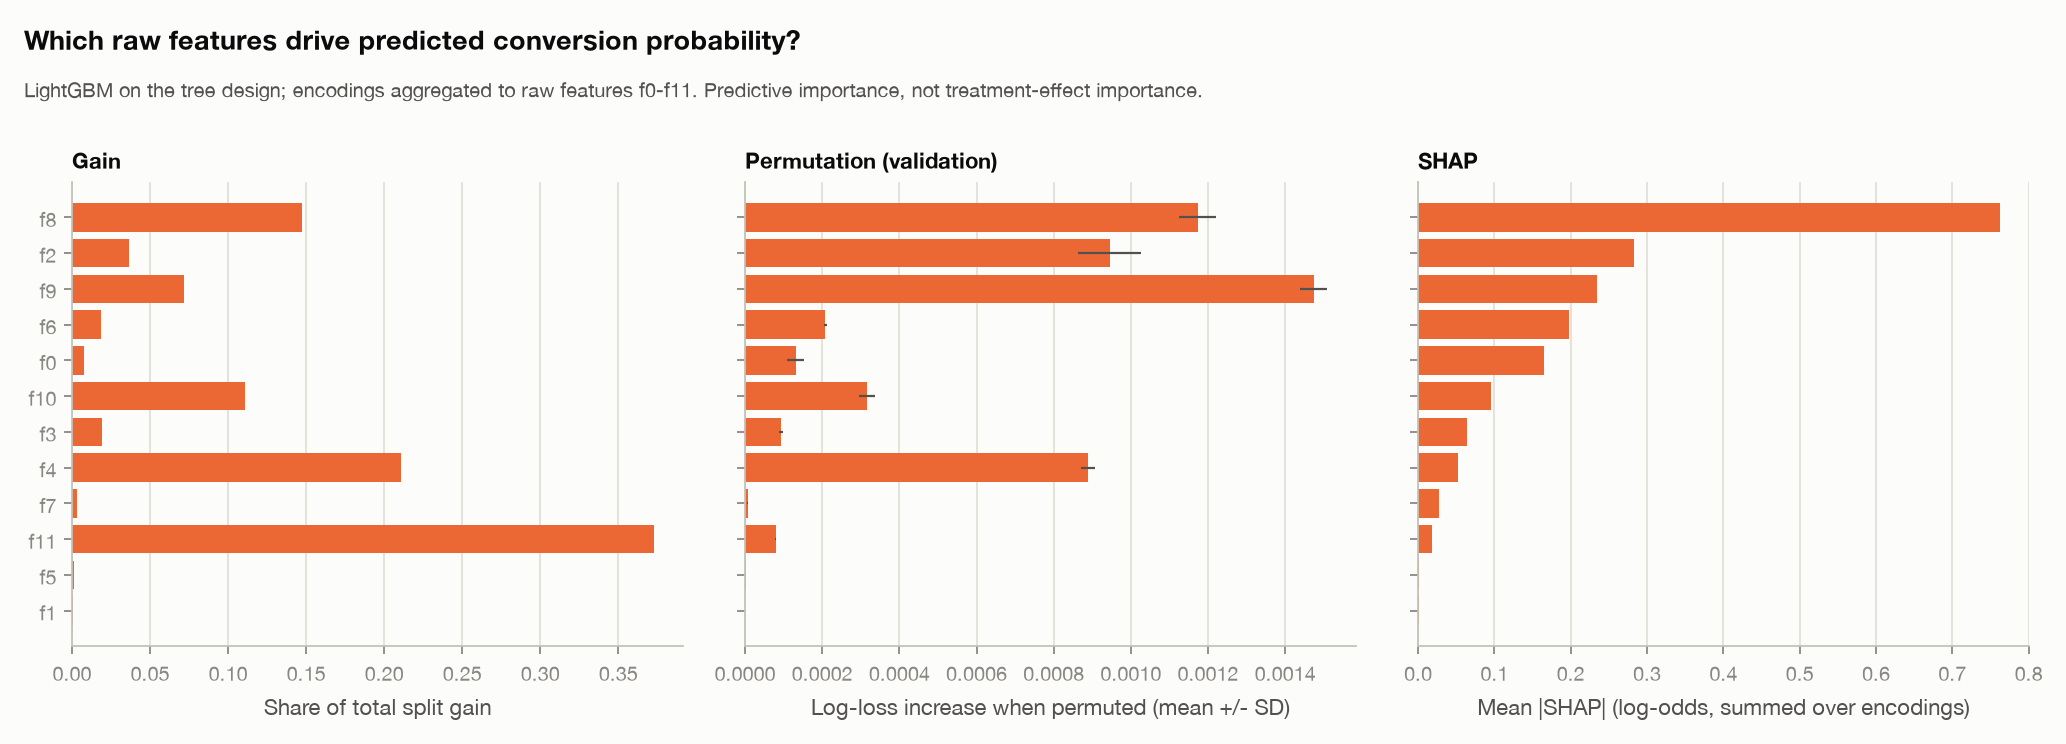

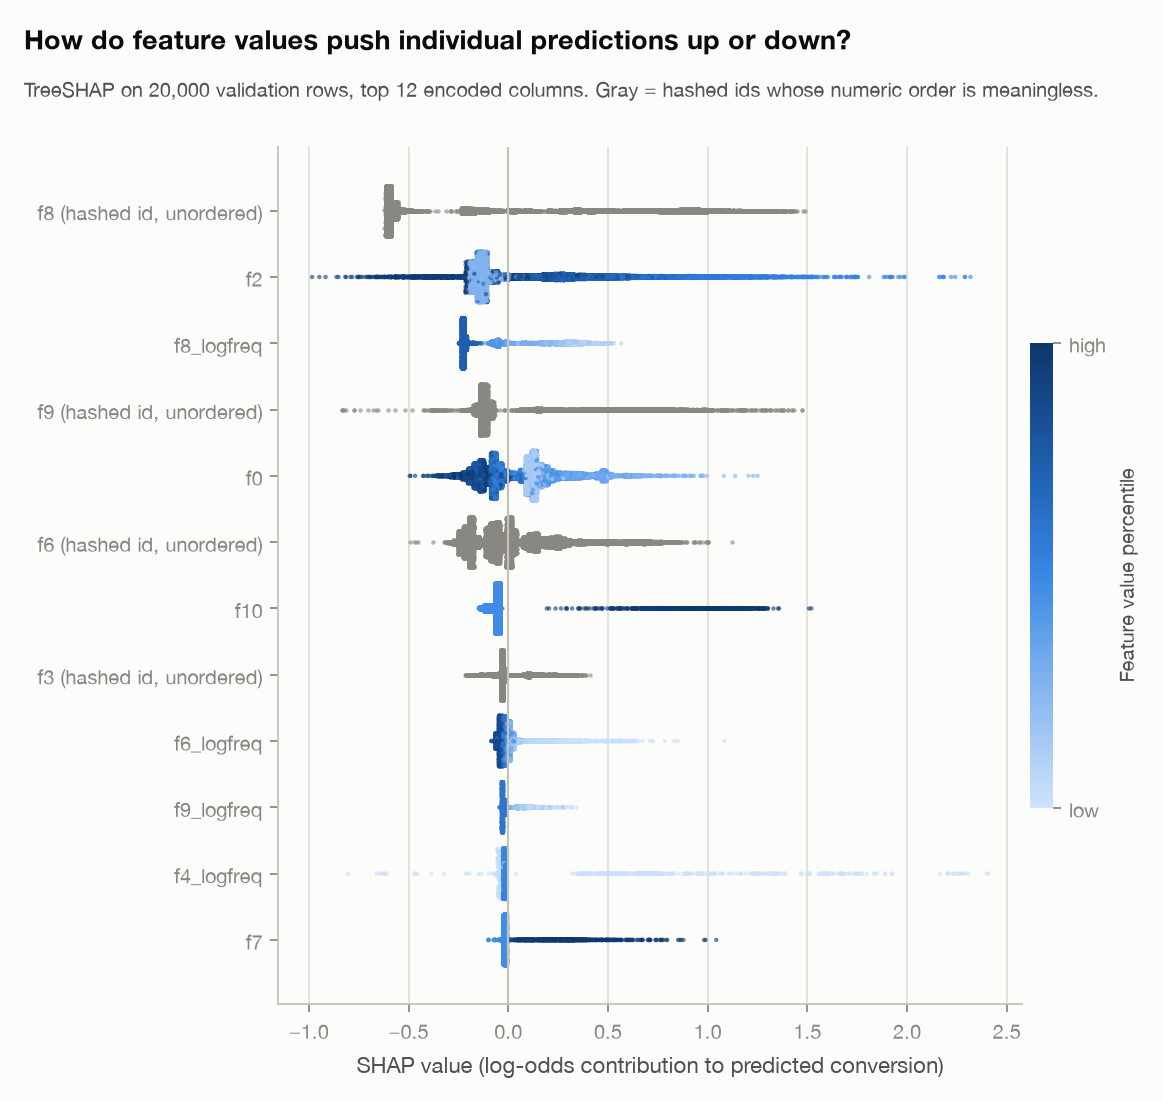

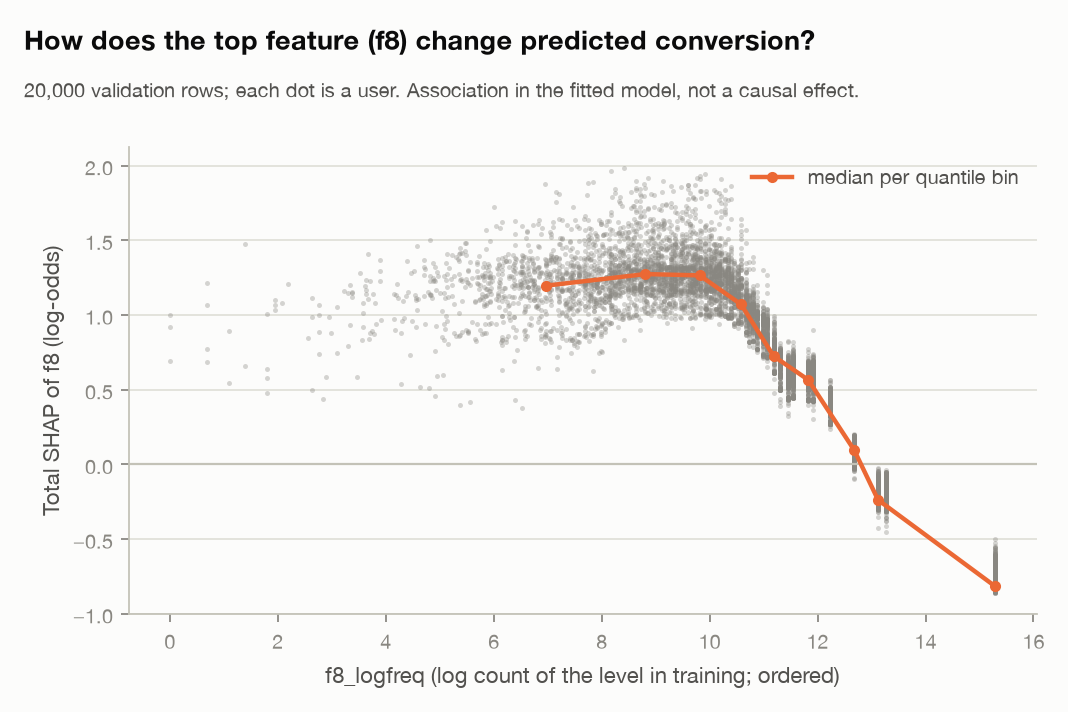

In [9]:
fig("predict_lr_coefficients"); fig("predict_importance"); fig("predict_shap_summary"); fig("predict_shap_dependence")